<a href="https://colab.research.google.com/github/gerryfrank10/ComputerVision/blob/main/cv_yolo_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torchvision
from torchvision import transforms as T
from PIL import Image
import torch

def detect_with_fasterrcnn(image_path, labels_of_interest):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    model.eval()

    transform = T.Compose([T.ToTensor()])
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img)

    with torch.no_grad():
        predictions = model([img_tensor])

    # COCO class labels
    coco_labels = [
        '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
        'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
        'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
        'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella',
        'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard',
        'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
        'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass', 'cup', 'fork',
        'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
        'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
        'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A', 'toilet',
        'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
        'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
        'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
    ]

    detections = []
    for i, box in enumerate(predictions[0]['boxes']):
        label_idx = predictions[0]['labels'][i].item()
        label = coco_labels[label_idx]
        if label in labels_of_interest:
            detections.append({
                'label': label,
                'bbox': box.tolist(),
                'score': predictions[0]['scores'][i].item()
            })

    return detections

In [35]:
detect_with_fasterrcnn('IMG_1629.jpeg', ['cell phone'])

[{'label': 'cell phone',
  'bbox': [2521.314697265625,
   1561.086669921875,
   3796.188720703125,
   2884.95556640625],
  'score': 0.997112512588501}]

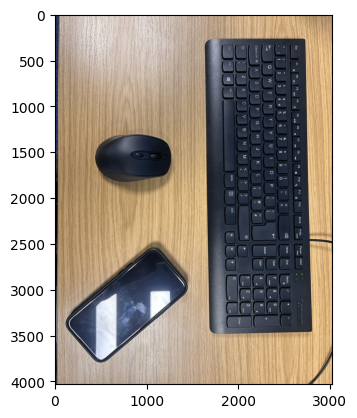

In [29]:
# prompt: Generate bounding boxes fro the items tht have over 0.7 confidence level

import torchvision
from torchvision import transforms as T
from PIL import Image
import torch

def detect_with_fasterrcnn(image_path, labels_of_interest, confidence_threshold=0.7):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    model.eval()

    transform = T.Compose([T.ToTensor()])
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img)

    with torch.no_grad():
        predictions = model([img_tensor])

    # COCO class labels
    coco_labels = [
        '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
        'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
        'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
        'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella',
        'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard',
        'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
        'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass', 'cup', 'fork',
        'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
        'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
        'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A', 'toilet',
        'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
        'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
        'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
    ]

    detections = []
    for i, box in enumerate(predictions[0]['boxes']):
        label_idx = predictions[0]['labels'][i].item()
        label = coco_labels[label_idx]
        score = predictions[0]['scores'][i].item()
        if label in labels_of_interest and score > confidence_threshold:
            detections.append({
                'label': label,
                'bbox': box.tolist(),
                'score': score
            })

    return detections
# Example usage
# Assuming 'IMG_1601.jpeg' is in the same directory
# Or provide the full path to the image
detections = detect_with_fasterrcnn('IMG_1629.jpeg', ['book'], confidence_threshold=0.8)
detections
img = cv2.imread('IMG_1629.jpeg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert from BGR to RGB

# Create figure and axes
fig, ax = plt.subplots(1)
ax.imshow(img)

# Draw bounding boxes
for detection in detections:
    x1, y1, x2, y2 = detection['bbox']
    width = x2 - x1
    height = y2 - y1
    rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    ax.text(x1, y1, f"{detection['label']} ({detection['score']:.2f})", color='r', fontsize=8)

plt.show()


In [7]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [19]:
from ultralytics import YOLO
import cv2

def detect_custom_items(image_path, labels_of_interest, confidence_threshold=0.2):
    # Load pretrained COCO model (knows 80 common classes)
    model = YOLO('yolo11n.pt')  # or yolov8s/m/l/x

    # Perform detection
    results = model(image_path)

    # Filter results
    detections = []
    for result in results:
        for box in result.boxes:
            label = model.names[int(box.cls)]
            if label in labels_of_interest and box.conf > confidence_threshold:
                detections.append({
                    'label': label,
                    'confidence': float(box.conf),
                    'bbox': box.xyxy[0].tolist()  # [x1,y1,x2,y2]
                })

    return detections

# Example usage
labels_i_want = ['person', 'car', 'book']
detections = detect_custom_items('IMG_1601.jpeg', labels_i_want)
print(detections)

100%|██████████| 5.35M/5.35M [00:00<00:00, 14.9MB/s]



image 1/1 /content/IMG_1601.jpeg: 480x640 1 cell phone, 2 books, 153.1ms
Speed: 4.0ms preprocess, 153.1ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)
[{'label': 'book', 'confidence': 0.6209635734558105, 'bbox': [1813.2696533203125, 628.4774780273438, 2698.2900390625, 1673.3118896484375]}, {'label': 'book', 'confidence': 0.32800033688545227, 'bbox': [1782.345458984375, 1760.274658203125, 2615.065185546875, 2427.61279296875]}]



image 1/1 /content/IMG_1629.jpeg: 640x480 2 mouses, 1 keyboard, 147.2ms
Speed: 3.9ms preprocess, 147.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)
[]


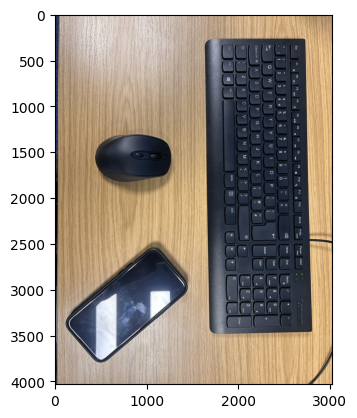

In [28]:
# prompt: can you draw the bounding boxes on the image

import torchvision
from torchvision import transforms as T
from PIL import Image
import torch
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def detect_custom_items(image_path, labels_of_interest, confidence_threshold=0.2):
    # Load pretrained COCO model (knows 80 common classes)
    model = YOLO('yolo11n.pt')  # or yolov8s/m/l/x

    # Perform detection
    results = model(image_path)

    # Filter results
    detections = []
    for result in results:
        for box in result.boxes:
            label = model.names[int(box.cls)]
            if label in labels_of_interest and box.conf > confidence_threshold:
                detections.append({
                    'label': label,
                    'confidence': float(box.conf),
                    'bbox': box.xyxy[0].tolist()  # [x1,y1,x2,y2]
                })

    return detections

# Example usage
labels_i_want = ['person', 'car', 'book']
detections = detect_custom_items('IMG_1629.jpeg', labels_i_want)
print(detections)

# Load the image
img = cv2.imread('IMG_1629.jpeg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert from BGR to RGB

# Create figure and axes
fig, ax = plt.subplots(1)
ax.imshow(img)

# Draw bounding boxes
for detection in detections:
    x1, y1, x2, y2 = detection['bbox']
    width = x2 - x1
    height = y2 - y1
    rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    ax.text(x1, y1, f"{detection['label']} ({detection['confidence']:.2f})", color='r', fontsize=8)

plt.show()
